In [ ]:
# Koppla Google Drive till Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


We start of by importing all the nessecary libraries and read the data

In [ ]:
import pandas as pd
import re
import html
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')
lemmatizer = WordNetLemmatizer()


file_path = '/content/drive/MyDrive/Big Data analytics/reddit_opinion_PSE_ISR.csv'
df = pd.read_csv(file_path)

cleaning_performance = [("Original Data", len(df))] #to track the performance of cleaning

print(f"Original size of data: {df.shape}")

Original size of data: (3125, 2)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Original size of data: (3125, 2)
Granularity: Each row represents a single Reddit comment/post and its corresponding sentiment label.

Now we check how many empty values there are and remove them:

In [ ]:
missing_before = df.isnull().sum().sum()
df = df.dropna().reset_index(drop=True)

cleaning_performance.append(("After Drop empty values", len(df)))

print(f"Missing values: {missing_before}")


Missing values: 0


There are 0 missing values.

Now we remove dublicates

In [ ]:

duplicates_before = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

cleaning_performance.append(("After Drop Duplicates", len(df)))

print(f"Dublicates removed:  {duplicates_before}")

Dublicates removed:  8


there were 8 dublicates removed.

now we remove outliers, extremly short or long words.

/tmp/ipykernel_4610/2068877978.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


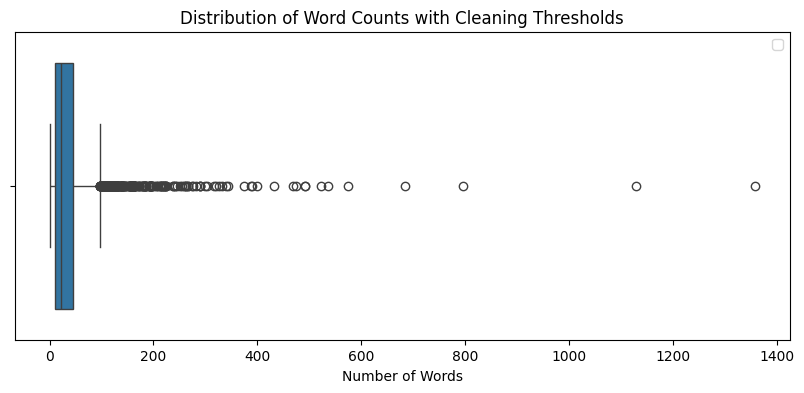

Number of outliers removed: 99


In [ ]:

df['word_count'] = df['self_text'].apply(lambda x: len(str(x).split())) #split and check length

#plot the boundaries with boxplots
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['word_count'])
plt.title('Distribution of Word Counts with Cleaning Thresholds')
plt.xlabel('Number of Words')
plt.legend()
plt.show()

#save the dataset for comparisons later
df_before_cleaning = df.copy()


outliers_before = len(df[(df['word_count'] < 2) | (df['word_count'] > 300)])
df = df[(df['word_count'] >= 2) & (df['word_count'] <= 300)]
df = df.drop(columns=['word_count'])

cleaning_performance.append(("After Outlier Removal", len(df)))

print(f"Number of outliers removed: {outliers_before}")

The boundaries are set to 2 and 300, as majority of data seems to be 5-10 words and the outliers (circles) become more and more separated around the 300 mark. This removed 99 rows

now we create a function to clean the data

In [ ]:
def cleaner_pipeline(text):
    text = str(text)

    #Solve HTML issues
    text = html.unescape(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'/s\b', '', text)

    #set everything to lowercase
    text = text.lower()

    # We noticed ' doesnt convert correctly, to simplyfy for the models, we switched all to words
    text = text.replace('â__t', " not").replace('â__s', " is").replace('â__re', " are")
    text = text.replace('â__ll', " will").replace('â__ve', " have").replace('â__m', " am")

    # We also did this for correctly formatted words, to simplify for the model
    text = text.replace("won't", "will not").replace("can't", "cannot")
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'m", " am", text)


    #Now we remove everything that's not letters or numbers
    text = re.sub(r'[^a-z0-9\s]', ' ', text) #Is this good, do we need to keep more stuff?

    #remove any extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize and lemmatization
    tokens = text.split()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]

    #remove any words shorter than 1 letter
    filtered_tokens = [word for word in lemmatized_tokens if len(word) > 1 or word in ['i', 'a']]

    return " ".join(filtered_tokens)

df['cleaned_text'] = df['self_text'].apply(cleaner_pipeline)


now we remove empty values again since we cleaned some rows

empty rows removed: 5


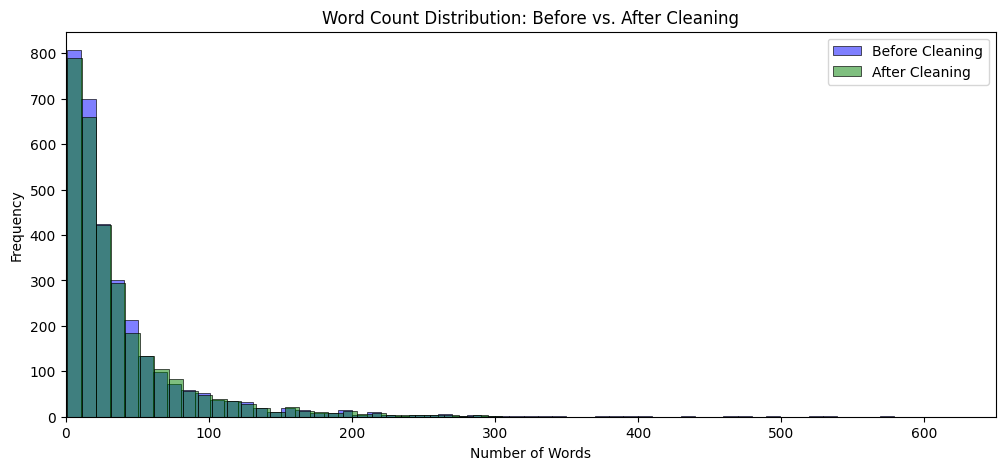

In [ ]:

empty_after = (df['cleaned_text'] == "").sum()
df = df[df['cleaned_text'] != ""]

cleaning_performance.append(("After Text Cleaning", len(df)))

print(f"empty rows removed: {empty_after}")

#plotting comparison before and after cleaning, calculates nr of words to compare
df_before_cleaning['word_count_before'] = df_before_cleaning['self_text'].apply(lambda x: len(str(x).split()))
df['word_count_after'] = df['cleaned_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 5))
sns.histplot(df_before_cleaning['word_count_before'], color='blue', alpha=0.5, label='Before Cleaning', binwidth=10)
sns.histplot(df['word_count_after'], color='green', alpha=0.5, label='After Cleaning', binwidth=10)
plt.title('Word Count Distribution: Before vs. After Cleaning')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.xlim(0, 650)
plt.show()

# Remove the temporary column for words count so its not saved in the file.
df = df.drop(columns=['word_count_after'])


Now check the final size of dataaset and save it.
This histogram shows a grouping of word count distribution, revealing that the vast majority of Reddit posts in our dataset are relatively short (clustering under 50 words). The visible shift from the blue "before cleaning" bars to the green "after cleaning" bars demonstrates the effectiveness of our preprocessing pipeline. The slight reduction in overall word count per post confirms the successful removal of noise such as URLs, HTML tags, and special characters.

/tmp/ipykernel_4610/1750438568.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=perf_df, x='Step', y='Row Count', palette='viridis')


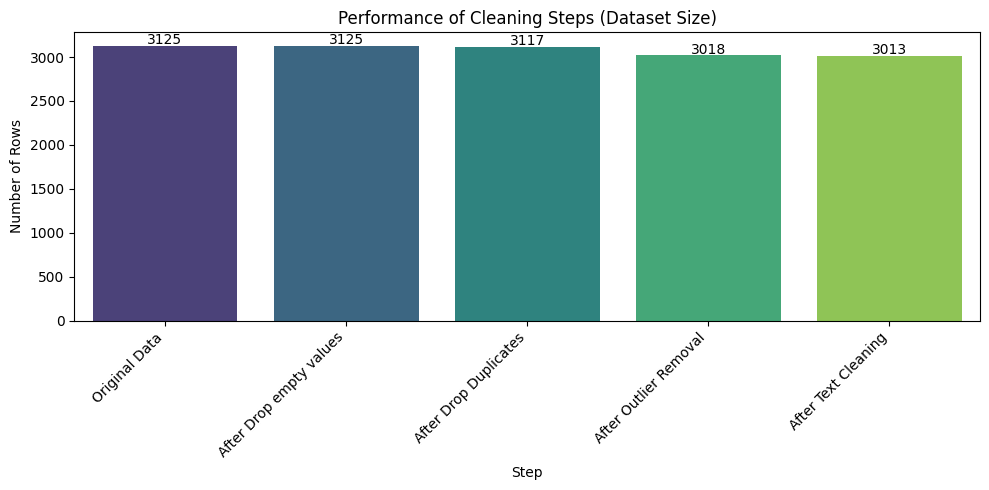


Final size of dataset: (3013, 3)


In [ ]:
perf_df = pd.DataFrame(cleaning_performance, columns=['Step', 'Row Count'])

plt.figure(figsize=(10, 5))
sns.barplot(data=perf_df, x='Step', y='Row Count', palette='viridis')
plt.title('Performance of Cleaning Steps (Dataset Size)')
plt.ylabel('Number of Rows')
plt.xticks(rotation=45, ha='right')

# Add the numbers on top of every stack
for index, value in enumerate(perf_df['Row Count']):
    plt.text(index, value + 20, str(value), ha='center')
plt.tight_layout()
plt.show()


print(f"\nFinal size of dataset: {df.shape}")

output_path = '/content/drive/MyDrive/Big Data analytics/PERFECT2_cleaned_reddit_opinion.csv'
df.to_csv(output_path, index=False)

so we went from 3125 to 3013 rows. The graph demonstrates how many rows each cleaning process romed. There we're no empty values, 8 duplicates, 99 outliers and 5 removed by text cleaning. This comes to show how all steps in the process are of importance, where the outlier removal removes majority of rows.